# Optimal Ansatz / Optimizer Combination

What combination of ansatz and optimizer results in the best objective function.

In [2]:
import time
start_time = time.time()
#from qiskit_ibm_provider import IBMProvider
#provider = IBMProvider()

In [3]:
# Standard imports
import numpy as np
import pandas as pd
import time
import warnings

# Qiskit 
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes, EfficientSU2
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit
from qiskit.primitives import Sampler
from qiskit_algorithms.optimizers import COBYLA, L_BFGS_B, ADAM, SLSQP, AQGD
from qiskit_algorithms.utils import algorithm_globals

# Visualization libraries
from matplotlib import pyplot as plt
import seaborn as sns
from qiskit.visualization import plot_histogram
from IPython.display import clear_output

# Machine learning and preprocessing
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.exceptions import ConvergenceWarning
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

from functools import partial

In [4]:
from sklearn.datasets import load_iris
iris_data = load_iris()
features = iris_data.data
labels = iris_data.target
features = MinMaxScaler().fit_transform(features)
algorithm_globals.random_seed = 4701

train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size = 0.8, random_state = algorithm_globals.random_seed)
num_features = features.shape[1]

In [5]:
sampler = Sampler()

In [6]:
objective_func_vals = []
plt.rcParams['figure.figsize'] = (12,6)
def callback_graph(weights, obj_func_eval):
             
    if combo_identifier not in objective_func_vals_dict:
        objective_func_vals_dict[combo_identifier] = []
    objective_func_vals_dict[combo_identifier].append(mean)

    clear_output(wait=True)
    for identifier, values in objective_func_vals_dict.items():
        plt.plot(values, label=identifier)
    
    plt.title('Objective function value against Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('Objective function value')
    plt.legend()
    plt.show()

In [9]:
feature_dimension = 4
optimizers = [COBYLA(maxiter=100)]#, SLSQP(maxiter=100)]
ansatzes = [EfficientSU2] #RealAmplitudes, 
reps_range = [3] #range(1, 5)

combinations = [
    {"optimizer": optimizer, "ansatz": ansatz(feature_dimension, reps=reps)}
    for optimizer in optimizers
    for ansatz in ansatzes
    for reps in reps_range
]

sampler = Sampler()


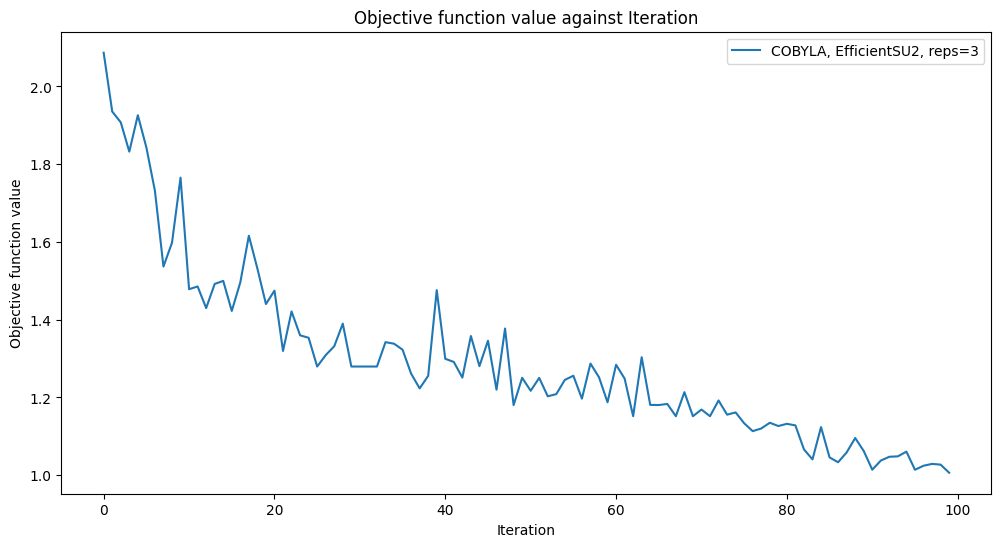

In [10]:
from functools import partial
import matplotlib.pyplot as plt
from IPython.display import clear_output


objective_func_vals_dict = {}


def callback_graph(combo_identifier, objective_func_vals_dict, eval_count, mean):
    if combo_identifier not in objective_func_vals_dict:
        objective_func_vals_dict[combo_identifier] = []
    objective_func_vals_dict[combo_identifier].append(mean)

    
    clear_output(wait=True)
    for identifier, values in objective_func_vals_dict.items():
        plt.plot(values, label=identifier)

    plt.title('Objective function value against Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('Objective function value')
    plt.legend()
    plt.show()

results = []

for combo in combinations:
    optimizer = combo["optimizer"]
    ansatz = combo["ansatz"]
    reps = ansatz.reps
    optimizer_name = type(optimizer).__name__
    ansatz_name = type(ansatz).__name__
    combo_identifier = f"{optimizer_name}, {ansatz_name}, reps={reps}"
    feature_map = ZZFeatureMap(feature_dimension=feature_dimension, reps=1)

    unique_callback = partial(callback_graph, combo_identifier, objective_func_vals_dict)
    
    vqc = VQC(feature_map=feature_map,
              ansatz=ansatz,
              optimizer=optimizer,
              callback=unique_callback,  
              sampler=sampler)

    
    objective_func_vals_dict[combo_identifier] = []
    
    start_time = time.time()
    vqc.fit(train_features, train_labels)
    elapsed_time = time.time() - start_time
    score = vqc.score(test_features, test_labels)

    results.append({
        "combo_identifier": combo_identifier,
        "optimizer": optimizer_name,
        "ansatz": ansatz_name,
        "ansatz_reps": reps,
        "training_time": elapsed_time,
        "score": score
    })

In [11]:
vqc.save("trained_model.model")

In [14]:
df_results = pd.DataFrame(results)

In [15]:
df_results

,combo_identifier,optimizer,ansatz,ansatz_reps,training_time,score
0,"COBYLA, EfficientSU2, reps=3",COBYLA,EfficientSU2,3,128.751039,0.866667
